<a href="https://colab.research.google.com/github/hcristiancruz2020-dev/Machine_Learning/blob/main/Copia_de_02_1_NN_Intro_Keras_resuelto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multilayer Percerptron Networks**
  (Keras and Tensorflow implementation)

**Librerias base para redes neuronales**

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import datasets


**Cargar datos**

In [ ]:
X, y = datasets.load_iris(return_X_y=True, as_frame=True)
y.unique()

array([0, 1, 2])

**Features**

In [ ]:
#Propiedades de flores
X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
print("Cantidad de flores:"+str(len(X)))

Cantidad de flores:150


**Classes**

In [ ]:
# Y guarda las clases de flores
y.unique() #Las clases existentes

array([0, 1, 2])

**Separacion de datos en entrenamiento (train) y prueba (test)**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [ ]:
print("Cantidad de flores para entrenamiento:"+str(len(X_train)))

Cantidad de flores para entrenamiento:120


**Diseño de la red neuronal**

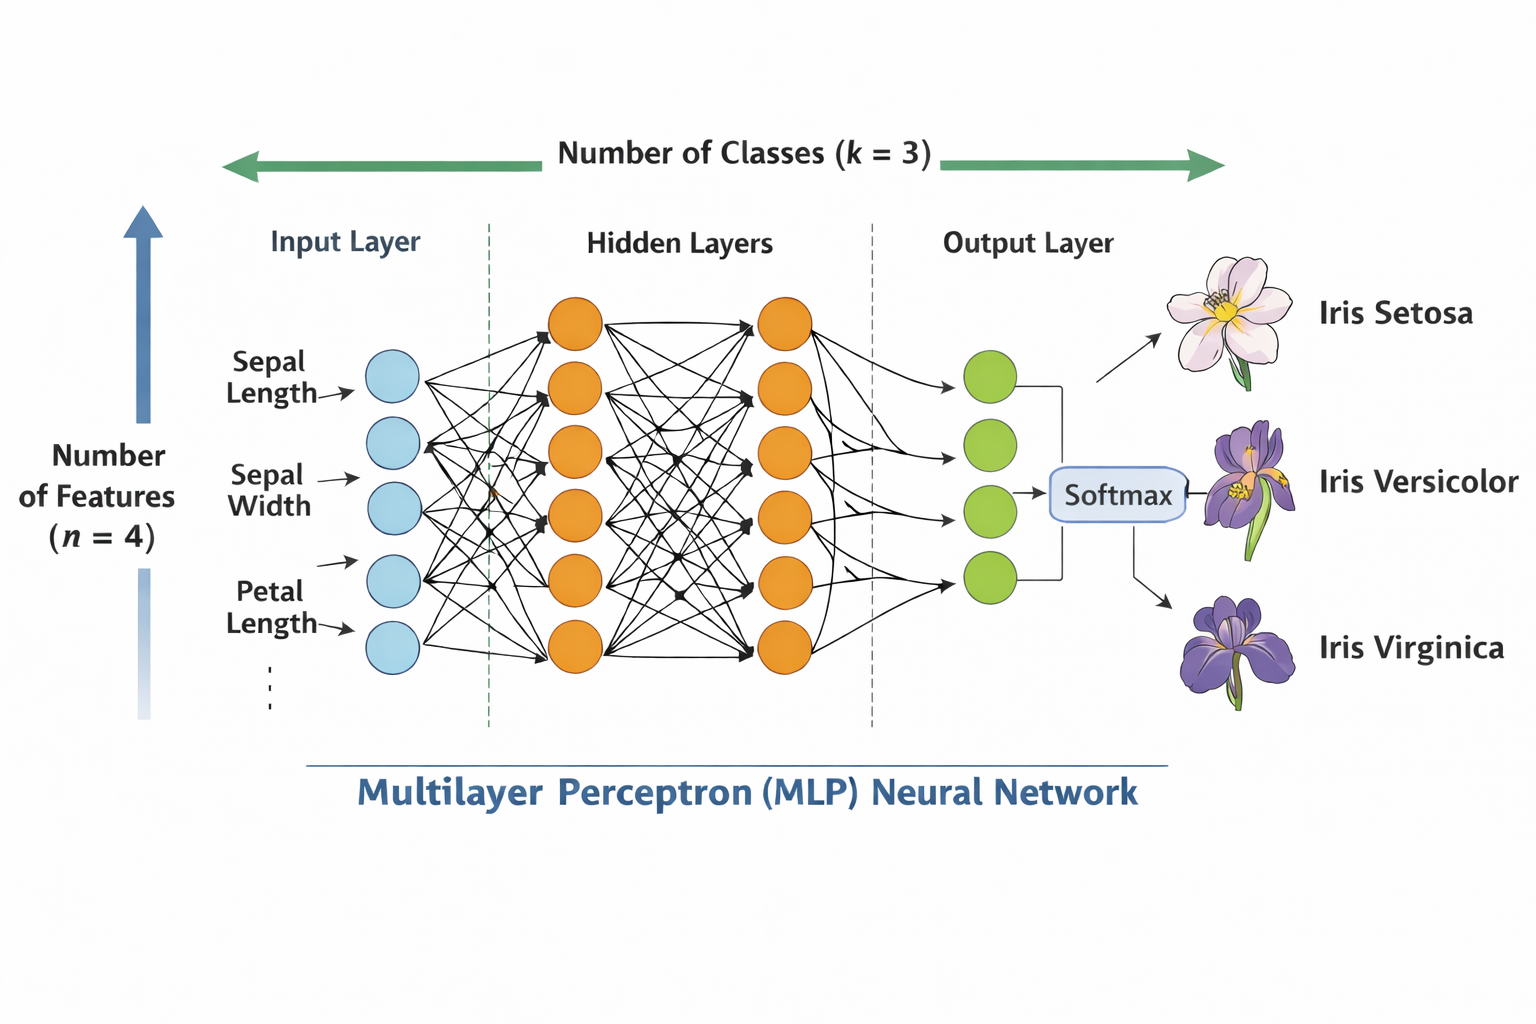

In [ ]:
# First, we initialize the model.
model = tf.keras.models.Sequential()

In [ ]:
# First our input layer. For this layer, and this layer only, we need to specify the size of our input. For our dataset this means the amount of columns in our X.
model.add(tf.keras.layers.Dense(4, activation=tf.nn.tanh, input_shape=(X.shape[1],)))
# Now some hidden layers
model.add(tf.keras.layers.Dense(6, activation=tf.nn.tanh))
model.add(tf.keras.layers.Dense(6, activation=tf.nn.tanh))
# Finally, our output layer. Since we have 3 possible classes, we need 3 output neurons.
# For a regression problem, we would have only 1. For an image creation network, we would have as many pixels as the image we wanted to create!
model.add(tf.keras.layers.Dense(3))
# A final layer with several output neurons gives us logits as results.
#We can do a final pass with a Softmax layer to turn them into percentages.
model.add(tf.keras.layers.Softmax())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
optim = tf.keras.optimizers.Adam(learning_rate=0.01)

In [ ]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=optim,metrics=['accuracy'])


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113 (452.00 B)

 Trainable params: 113 (452.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train.values, y_train.values,
        validation_data=(X_test.values, y_test.values),
        epochs = 50,
        batch_size=120)


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3250 - loss: 1.0223 - val_accuracy: 0.4000 - val_loss: 0.9896
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.4083 - loss: 0.9835 - val_accuracy: 0.3667 - val_loss: 0.9545
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.4750 - loss: 0.9482 - val_accuracy: 0.6333 - val_loss: 0.9185
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.8000 - loss: 0.9124 - val_accuracy: 0.7000 - val_loss: 0.8818
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.8333 - loss: 0.8761 - val_accuracy: 0.7333 - val_loss: 0.8464
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.7750 - loss: 0.8413 - val_accuracy: 0.7333 - val_loss: 0.8139
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.7583 - loss: 0.8096 - val_accuracy: 0.7333 - val_loss: 0.7849
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.7333 - loss: 0.7813 - val_accuracy: 0.7333 - val_loss: 0.

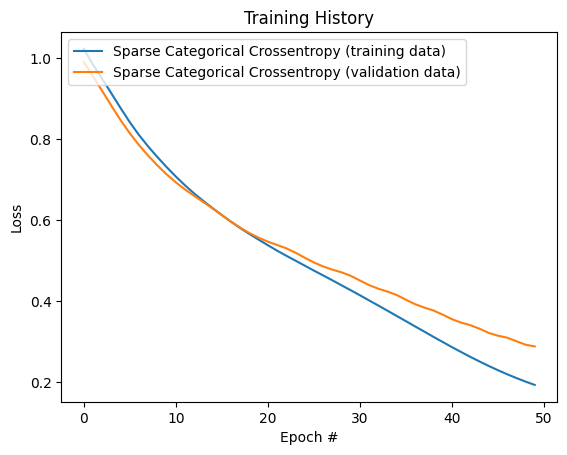

In [ ]:
plt.plot(history.history['loss'], label='Sparse Categorical Crossentropy (training data)')
plt.plot(history.history['val_loss'], label='Sparse Categorical Crossentropy (validation data)')
plt.title('Training History')
plt.ylabel('Loss')
plt.xlabel('Epoch #')
plt.legend(loc="upper left")
plt.show()


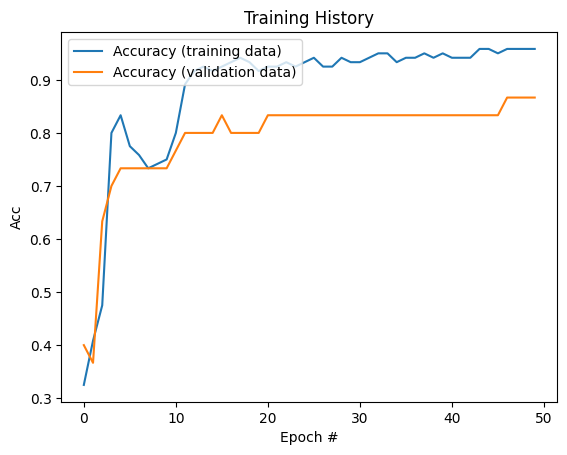

In [ ]:
plt.plot(history.history['accuracy'], label='Accuracy (training data)')
plt.plot(history.history['val_accuracy'], label='Accuracy (validation data)')
plt.title('Training History')
plt.ylabel('Acc')
plt.xlabel('Epoch #')
plt.legend(loc="upper left")
plt.show()

In [ ]:
model.predict(X_test[:1])

#10: Ver el desempeño
predictions = model.predict(X_test)
y_pred=[]
for idx, prediction in enumerate(predictions):
  y_pred.append(np.argmax(prediction))
  print('We predict: '+str(y_pred[idx])+'. Real Species was: '+str(y_test.iloc[idx]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
We predict: 2. Real Species was: 1
We predict: 0. Real Species was: 0
We predict: 2. Real Species was: 2
We predict: 1. Real Species was: 1
We predict: 1. Real Species was: 1
We predict: 0. Real Species was: 0
We predict: 1. Real Species was: 1
We predict: 1. Real Species was: 2
We predict: 1. Real Species was: 1
We predict: 1. Real Species was: 1
We predict: 1. Real Species was: 2
We predict: 0. Real Species was: 0
We predict: 0. Real Species was: 0
We predict: 0. Real Species was: 0
We predict: 0. Real Species was: 0
We predict: 1. Real Species was: 1
We predict: 2. Real Species was: 2
We predict: 1. Real Species was: 1
We predict: 1. Real Species was: 1
We predict: 2. Real Species was: 2
We predict: 0. Real Species was: 0
We predict: 2. Real Species was: 2
We predict: 0. Real Species was: 0
We predict: 2. Real Species was: 2
We predict: 2. Real Species was: 2
We predict: 1. Real Species was: 2
We predict: 2.

<Axes: >

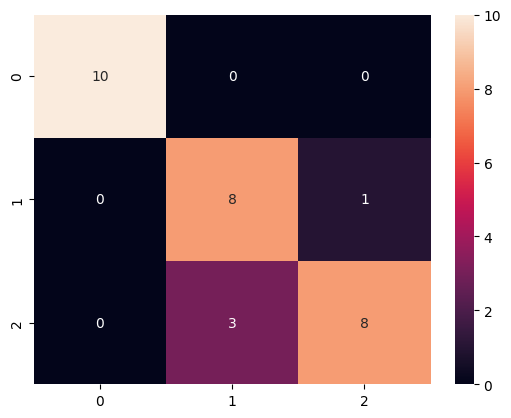

In [ ]:
#Calculate accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

#Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm
#Plot heat map
import seaborn as sns
sns.heatmap(cm, annot=True)



# **Non-linear separable problems**

**Circles**

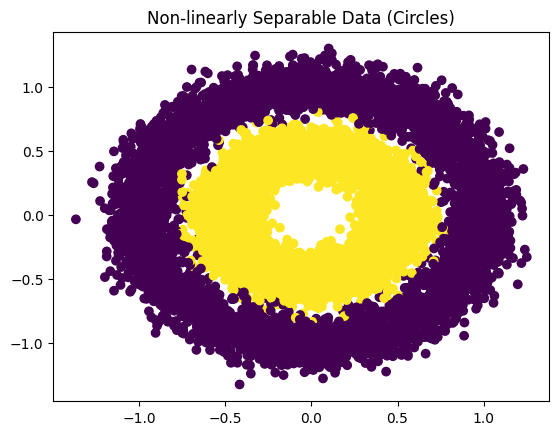

In [ ]:
#Generate a non-linear separable set

from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

# Generate data
X, y = make_circles(n_samples=10000, noise=0.1, factor=0.5, random_state=42)

# Plot
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Non-linearly Separable Data (Circles)")
plt.show()

In [ ]:
#Design a minimal Neural Network

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(2, activation=tf.nn.tanh, input_shape=(X.shape[1],)))#input layer
model.add(tf.keras.layers.Dense(1, activation=tf.nn.tanh))#Hidden layer
#model.add(tf.keras.layers.Dense(8, activation=tf.nn.tanh))
model.add(tf.keras.layers.Dense(1))# Output layer
model.add(tf.keras.layers.Activation('sigmoid'))

optim = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=optim,metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

#train model
history = model.fit(X_train, y_train,
        validation_data=(X_test, y_test),
        epochs = 50,
        batch_size=120)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5755 - loss: 0.7027 - val_accuracy: 0.5691 - val_loss: 0.6760
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5997 - loss: 0.6633 - val_accuracy: 0.6097 - val_loss: 0.6491
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6464 - loss: 0.6335 - val_accuracy: 0.6588 - val_loss: 0.6158
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7346 - loss: 0.5799 - val_accuracy: 0.7903 - val_loss: 0.5245
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8027 - loss: 0.4943 - val_accuracy: 0.8079 - val_loss: 0.4604
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8048 - loss: 0.4633 - val_accuracy: 0.8115 - val_loss: 0.4441
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8049 - loss: 0.4513 - val_accuracy: 0.8109 - val_loss: 0.4354
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8030 - loss: 0.4447 - val_accuracy: 0.8109 - val_loss:

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

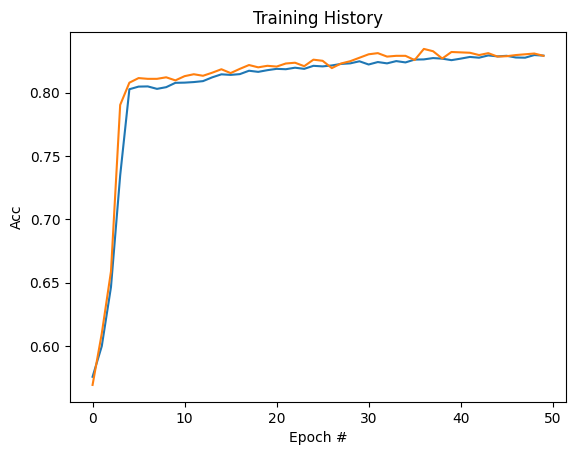

In [ ]:
#plot accuracy and val_accuracy
plt.plot(history.history['accuracy'], label='Accuracy (training data)')
plt.plot(history.history['val_accuracy'], label='Accuracy (validation data)')
plt.title('Training History')
plt.ylabel('Acc')
plt.xlabel('Epoch #')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

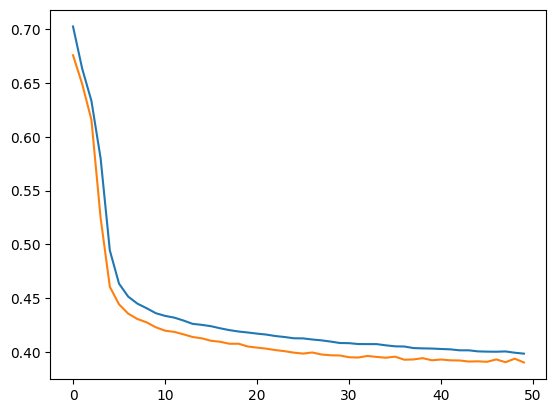

In [ ]:
#plot loss
plt.plot(history.history['loss'], label=' Crossentropy (training data)')
plt.plot(history.history['val_loss'], label=' Crossentropy (validation data)')
plt

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


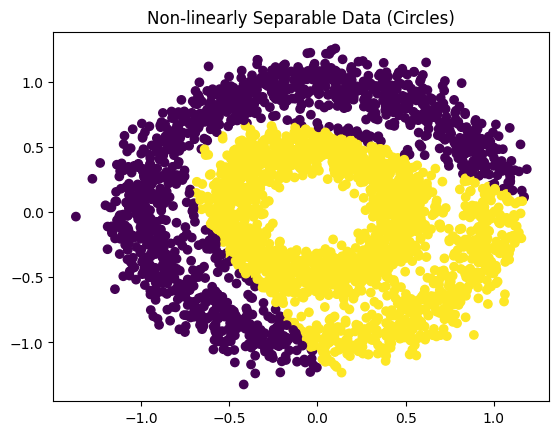

In [ ]:
#plot test classification
import numpy as np
import matplotlib.pyplot as plt

y_pred=[]
for idx, prediction in enumerate(model.predict(X_test)):
  y_pred.append(np.round(prediction))

#plot data and predictions
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)
plt.title("Non-linearly Separable Data (Circles)")
plt.show()

**Moons**

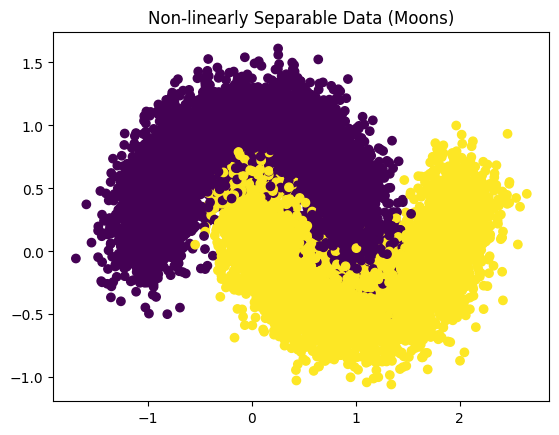

In [ ]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=10000, noise=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Non-linearly Separable Data (Moons)")
plt.show()

**Exercise:** Design a Multilayer Perceptron Network to solve this non-linear separable problem.

**1. Split dataset**

In [ ]:
#Your code here
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (7000, 2)
Test: (3000, 2)


**2. Design MLPN**

In [ ]:
#Your code here
import tensorflow as tf

model = tf.keras.models.Sequential()

# Input layer
model.add(tf.keras.layers.Dense(8, activation='tanh', input_shape=(2,)))

# Hidden layers
model.add(tf.keras.layers.Dense(8, activation='tanh'))
model.add(tf.keras.layers.Dense(8, activation='tanh'))

# Output layer
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177 (708.00 B)

 Trainable params: 177 (708.00 B)

 Non-trainable params: 0 (0.00 B)

**3. Train model**

In [ ]:
#Your code here
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    verbose=1
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8537 - loss: 0.3252 - val_accuracy: 0.8843 - val_loss: 0.2700
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9283 - loss: 0.1851 - val_accuracy: 0.9590 - val_loss: 0.1040
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9630 - loss: 0.0995 - val_accuracy: 0.9557 - val_loss: 0.1157
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9681 - loss: 0.0873 - val_accuracy: 0.9643 - val_loss: 0.0887
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9679 - loss: 0.0835 - val_accuracy: 0.9623 - val_loss: 0.0905
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9690 - loss: 0.0822 - val_accuracy: 0.9667 - val_loss: 0.0804
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9707 - loss: 0.0788 - val_accuracy: 0.9680 - val_loss: 0.0838
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9689 - loss: 0.0837 - val_accuracy: 0.

**4. Plot the training metrics (accuracy and loss function)**

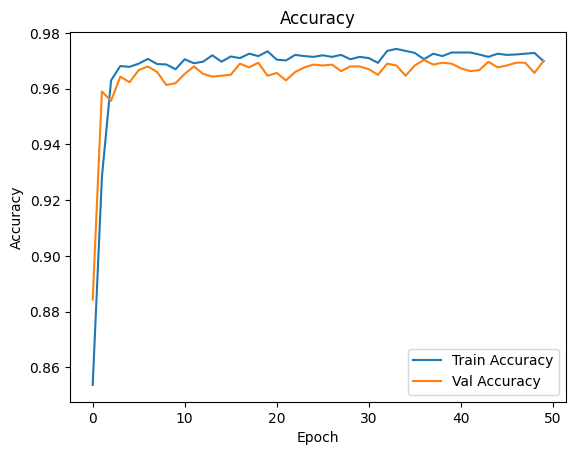

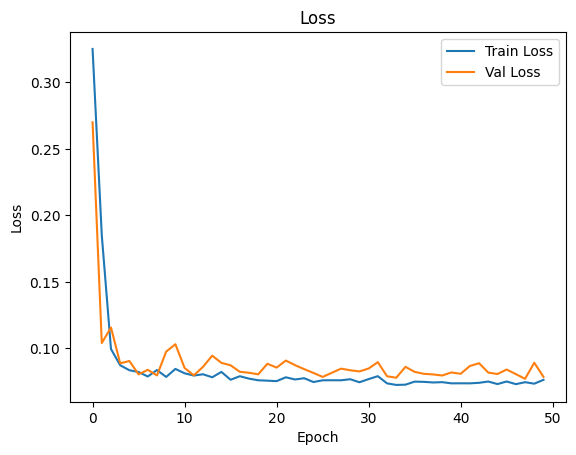

In [ ]:
#Your code here
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**5. Inference using the test data**

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


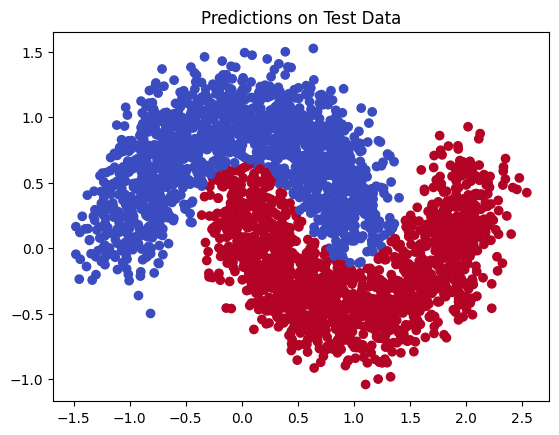

In [ ]:
#Your code here
import numpy as np

predictions = model.predict(X_test)
y_pred = (predictions > 0.5).astype(int)

plt.scatter(X_test[:,0], X_test[:,1], c=y_pred.flatten(), cmap='coolwarm')
plt.title("Predictions on Test Data")
plt.show()

**6. Evaluate the prediction**

Accuracy: 0.97

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1539
           1       0.96      0.98      0.97      1461

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



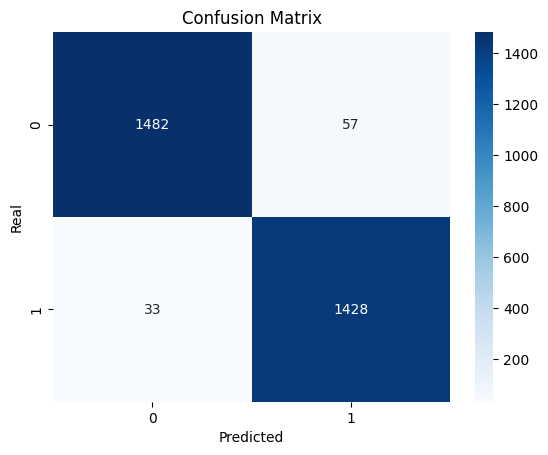

In [ ]:
#Your code here
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

Significa que el modelo clasificó correctamente:

97% de 3000=2910

Aproximadamente 2910 observaciones correctas.

**Clase 0**

Precision = 0.98
Recall = 0.96
F1-score = 0.97

Muy buen desempeño.

**Clase 1**

Precision = 0.96
Recall = 0.98
F1-score = 0.97

También excelente.

Conclusion:

La red neuronal logró aprender una frontera no lineal entre las dos lunas.

Eso demuestra que el MLP superó un clasificador lineal tradicional.